In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
import datetime
import json
import re
import gensim
from gensim import corpora, models
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.stem.porter import *
import nltk
# nltk.download('wordnet')
import random
import multiprocessing
from collections import defaultdict
from gensim.models import Word2Vec
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))

In [2]:
base_path = '/home/luxiaoling/wukun/MIND/data/'

In [3]:
behavior_train_df = pd.read_csv(base_path+'train/behaviors.tsv', sep='\t', index_col=0, 
                         names=['impr_id', 'uid', 'impr_time', 'history', 'cur_impr'])
behavior_train_df.head()

,uid,impr_time,history,cur_impr
impr_id,,,,
1,U87243,11/10/2019 11:30:54 AM,N8668 N39081 N65259 N79529 N73408 N43615 N2937...,N78206-0 N26368-0 N7578-0 N58592-0 N19858-0 N5...
2,U598644,11/12/2019 1:45:29 PM,N56056 N8726 N70353 N67998 N83823 N111108 N107...,N47996-0 N82719-0 N117066-0 N8491-0 N123784-0 ...
3,U532401,11/13/2019 11:23:03 AM,N128643 N87446 N122948 N9375 N82348 N129412 N5...,N103852-0 N53474-0 N127836-0 N47925-1
4,U593596,11/12/2019 12:24:09 PM,N31043 N39592 N4104 N8223 N114581 N92747 N1207...,N38902-0 N76434-0 N71593-0 N100073-0 N108736-0...
5,U239687,11/14/2019 8:03:01 PM,N65250 N122359 N71723 N53796 N41663 N41484 N11...,N76209-0 N48841-0 N67937-0 N62235-0 N6307-0 N3...


In [4]:
behavior_val_df = pd.read_csv(base_path+'dev/behaviors.tsv', sep='\t', index_col=0, 
                         names=['impr_id', 'uid', 'impr_time', 'history', 'cur_impr'])
behavior_val_df.head()

,uid,impr_time,history,cur_impr
impr_id,,,,
1,U134050,11/15/2019 8:55:22 AM,N12246 N128820 N119226 N4065 N67770 N33446 N10...,N91737-0 N30206-0 N54368-0 N117802-0 N18190-0 ...
2,U254959,11/15/2019 11:42:35 AM,N34011 N9375 N67397 N7936 N118985 N109453 N103...,N119999-0 N24958-0 N104054-0 N33901-0 N9250-0 ...
3,U499841,11/15/2019 9:08:21 AM,N63858 N26834 N6379 N85484 N15229 N65119 N1047...,N18190-0 N89764-0 N91737-0 N54368-0 N49978-1 N...
4,U107107,11/15/2019 5:50:31 AM,N12959 N8085 N18389 N3758 N9740 N90543 N129790...,N122944-1 N18190-0 N55801-0 N59297-0 N128045-0...
5,U492344,11/15/2019 5:02:25 AM,N109183 N48453 N85005 N45706 N98923 N46069 N35...,N64785-0 N82503-0 N32993-0 N122944-0 N29160-0 ...


In [5]:
behavior_train_df.shape, behavior_val_df.shape

((2232748, 4), (376471, 4))

In [7]:
# 根据user采样
user_list = list(set(behavior_train_df.uid.unique()) | set(behavior_val_df.uid.unique()))
print(len(user_list))

750434


In [8]:
user_sample = set(np.random.choice(user_list, size=200000, replace=False))
behavior_train_df = behavior_train_df[behavior_train_df['uid'].isin(user_sample)].reset_index()
behavior_val_df = behavior_val_df[behavior_val_df['uid'].isin(user_sample)].reset_index()
behavior_train_df.shape, behavior_val_df.shape

((596328, 5), (100548, 5))

# 训练数据集可视化分析

In [10]:
def utc2local(impr_time):
    date_str, time_str = impr_time.split(maxsplit=1)
    utc_str = datetime.datetime.strptime(date_str, '%m/%d/%Y').strftime('%Y-%m-%d') + ' ' + datetime.datetime.strptime(time_str, '%I:%M:%S %p').strftime('%H:%M:%S')
    utc_datetime = datetime.datetime.strptime(utc_str, '%Y-%m-%d %H:%M:%S')
    dt_str = utc_datetime.strftime('%Y-%m-%d %H:%M:%S')
    return dt_str
behavior_train_df['impr_datetime'] = behavior_train_df['impr_time'].apply(utc2local)
behavior_val_df['impr_datetime'] = behavior_val_df['impr_time'].apply(utc2local)


In [11]:
behavior_train_df.sort_values(by='impr_datetime', inplace=True)
behavior_val_df.sort_values(by='impr_datetime', inplace=True)

In [17]:
import datetime, math
end_date = datetime.datetime(2019, 11, 15)
datetime_df = behavior_train_df.impr_datetime.apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d %H:%M:%S'))
behavior_train_df['week'] = datetime_df.apply(lambda x: x.weekday())
behavior_train_df['hour'] = datetime_df.apply(lambda x: x.hour)
interval_df = datetime_df.apply(lambda x: end_date - x)
behavior_train_df['relative_seconds'] = interval_df.apply(lambda x: x.seconds + x.days * 24 * 3600)
behavior_train_df['relative_days'] = behavior_train_df['relative_seconds'].apply(lambda x: math.ceil(x / (24 * 3600)))
behavior_train_df['relative_hours'] = behavior_train_df['relative_seconds'].apply(lambda x: math.ceil(x / 3600))
behavior_train_df.head()

,impr_id,uid,impr_time,history,cur_impr,impr_datetime,week,hour,relative_seconds,relative_days,relative_hours
294431,1104144,U495159,11/9/2019 12:00:13 AM,N88765 N74317 N63723 N121794 N95711 N64341 N75...,N104437-0 N76810-0 N98657-0 N25492-0 N108809-0...,2019-11-09 00:00:13,5,0,518387,6,144
258173,967559,U251164,11/9/2019 12:00:24 AM,N42703 N126834 N118005 N13066 N43872 N48258 N1...,N79990-0 N59303-0 N65783-0 N18956-0 N2198-0 N9...,2019-11-09 00:00:24,5,0,518376,6,144
6268,23432,U515173,11/9/2019 12:00:25 AM,N10243 N14424 N55661 N114369 N70847 N123633 N8...,N4789-0 N17547-0 N104610-0 N37049-0 N92463-0 N...,2019-11-09 00:00:25,5,0,518375,6,144
424469,1591237,U528649,11/9/2019 12:00:37 AM,N116996 N31266 N71082 N113593 N107137 N49262 N...,N2198-0 N79990-0 N18956-0 N119284-0 N92613-0 N...,2019-11-09 00:00:37,5,0,518363,6,144
525793,1969101,U701987,11/9/2019 12:00:41 AM,N119674 N128483 N74723 N64141 N25892,N17456-0 N62003-0 N129463-0 N25492-0 N18956-0 ...,2019-11-09 00:00:41,5,0,518359,6,144


In [18]:
val_datetime_df = behavior_val_df.impr_datetime.apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d %H:%M:%S'))
behavior_val_df['week'] = val_datetime_df.apply(lambda x: x.weekday())
behavior_val_df['hour'] = val_datetime_df.apply(lambda x: x.hour)
val_interval_df = val_datetime_df.apply(lambda x: end_date - x)
behavior_val_df['relative_days'] = val_interval_df.apply(lambda x: 0)
behavior_val_df['relative_seconds'] = val_interval_df.apply(lambda x: - x.seconds)
behavior_val_df['relative_hours'] = behavior_val_df['relative_seconds'].apply(lambda x: math.ceil(x / 3600))
behavior_val_df.head()

,impr_id,uid,impr_time,history,cur_impr,impr_datetime,week,hour,relative_days,relative_seconds,relative_hours
22324,83071,U129523,11/15/2019 12:00:10 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N82503-0 N80770-0 N32993-0 N62800-0 N83707-1 N...,2019-11-15 00:00:10,4,0,0,-86390,-23
88010,329281,U411819,11/15/2019 12:00:19 AM,N89998 N79285 N60132 N26417 N102152 N108312 N8...,N100425-0 N40742-0 N83707-0 N73303-0 N26122-0 ...,2019-11-15 00:00:19,4,0,0,-86381,-23
42284,157161,U450360,11/15/2019 12:00:27 AM,NaN,N26122-0 N78508-0 N68624-0 N82503-0 N118623-1 ...,2019-11-15 00:00:27,4,0,0,-86373,-23
91396,342401,U423393,11/15/2019 12:00:32 AM,N1396 N106492 N70947 N42796 N45124 N86153 N446...,N56139-0 N96473-0 N45410-0 N121136-0 N63322-0 ...,2019-11-15 00:00:32,4,0,0,-86368,-23
19038,71022,U145343,11/15/2019 12:00:39 AM,N107095 N27258 N41484 N111654 N22950 N96516 N1...,N14857-0 N104054-0 N110967-0 N121411-0 N121375...,2019-11-15 00:00:39,4,0,0,-86361,-23


In [19]:
# save
save_path_train = base_path + 'train/behavior_sample.tsv'
save_path_val = base_path + 'dev/behavior_sample.tsv'
behavior_train_df[['uid', 'impr_datetime', 'week', 'hour', 'relative_days', 'relative_hours', 'relative_seconds', 'history', 'cur_impr']].to_csv(save_path_train, sep='\t', header=False, index=False)
behavior_val_df[['uid', 'impr_datetime', 'week', 'hour', 'relative_days', 'relative_hours', 'relative_seconds', 'history', 'cur_impr']].to_csv(save_path_val, sep='\t', header=False, index=False)


In [20]:
# 缺失值分析
behavior_train_df.isnull().sum()

impr_id                 0
uid                     0
impr_time               0
history             12000
cur_impr                0
impr_datetime           0
week                    0
hour                    0
relative_seconds        0
relative_days           0
relative_hours          0
dtype: int64

In [21]:
behavior_val_df.isnull().sum()

impr_id                0
uid                    0
impr_time              0
history             3073
cur_impr               0
impr_datetime          0
week                   0
hour                   0
relative_days          0
relative_seconds       0
relative_hours         0
dtype: int64

In [24]:
def get_seq_len(field):
    try:
        return len(field.split())
    except Exception as e:
        return 0
behavior_train_df['history_len'] = behavior_train_df['history'].apply(get_seq_len)
behavior_train_df['cur_impr_len'] = behavior_train_df['cur_impr'].apply(get_seq_len)

behavior_val_df['history_len'] = behavior_val_df['history'].apply(get_seq_len)
behavior_val_df['cur_impr_len'] = behavior_val_df['cur_impr'].apply(get_seq_len)

In [25]:
def get_pos_num(cur_impr):
    flags = [int(x[-1]) for x in cur_impr.split()]
    return sum(flags)
behavior_train_df['pos_num'] = behavior_train_df['cur_impr'].apply(get_pos_num)
behavior_val_df['pos_num'] = behavior_val_df['cur_impr'].apply(get_pos_num)

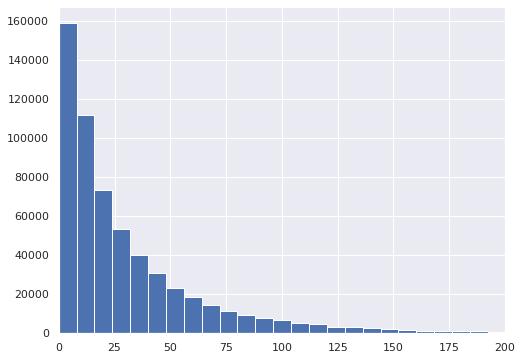

In [26]:
plt.figure(figsize=(8, 6))
behavior_train_df['history_len'].hist(bins=100)
plt.xlim(0, 200)
plt.show()

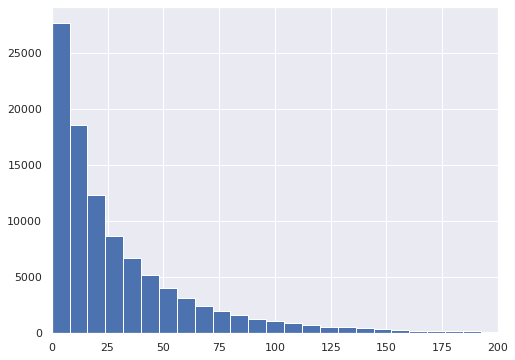

In [27]:
plt.figure(figsize=(8, 6))
behavior_val_df['history_len'].hist(bins=100)
plt.xlim(0, 200)
plt.show()

In [28]:
behavior_train_df.history_len.quantile([0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

0.90     80.0
0.91     84.0
0.92     90.0
0.93     96.0
0.94    103.0
0.95    111.0
0.96    123.0
0.97    136.0
0.98    155.0
0.99    192.0
Name: history_len, dtype: float64

In [29]:
behavior_val_df.history_len.quantile([0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

0.90     79.0
0.91     83.0
0.92     89.0
0.93     95.0
0.94    102.0
0.95    110.0
0.96    120.0
0.97    134.0
0.98    152.0
0.99    189.0
Name: history_len, dtype: float64

In [30]:
pos_num_all = behavior_train_df.pos_num.sum()
impr_num_all = behavior_train_df.cur_impr_len.sum()
print(pos_num_all, impr_num_all, float(pos_num_all) / impr_num_all)

904503 22296181 0.04056762007807525


In [31]:
pos_num_all = behavior_val_df.pos_num.sum()
impr_num_all = behavior_val_df.cur_impr_len.sum()
print(pos_num_all, impr_num_all, float(pos_num_all) / impr_num_all)

153454 3774306 0.04065754075053798


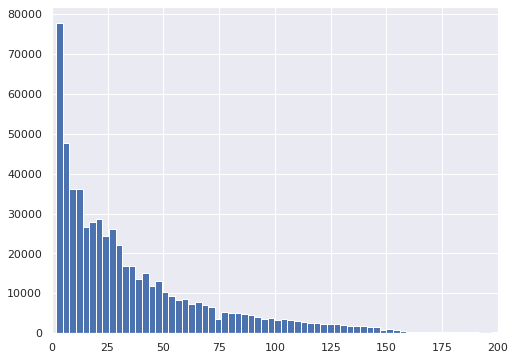

In [32]:
plt.figure(figsize=(8, 6))
behavior_train_df['cur_impr_len'].hist(bins=100)
plt.xlim(0, 200)
plt.show()

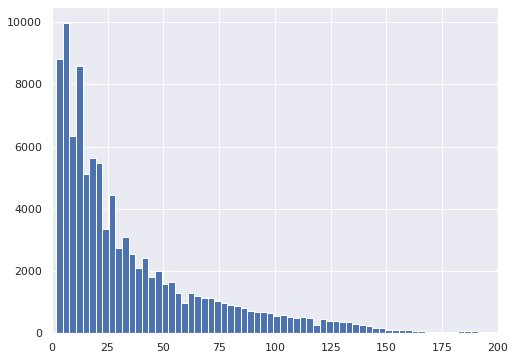

In [33]:
plt.figure(figsize=(8, 6))
behavior_val_df['cur_impr_len'].hist(bins=100)
plt.xlim(0, 200)
plt.show()

In [35]:
# 统计验证集中 新用户比例 和 新new比例
uid_set_train = set(behavior_train_df['uid'])
uid_set_val = set(behavior_val_df['uid'])
new_user_set = uid_set_val - uid_set_train
len(uid_set_train), len(uid_set_val), len(new_user_set), len(new_user_set) / len(uid_set_val)

(189658, 68435, 10342, 0.15112150215532988)

In [38]:
def get_news_set(df, history=False):
    history_set = set()
    impr_set = set()
    for imprs in df['cur_impr']:
        news = [x[:-2] for x in imprs.split()]
        impr_set.update(news)
    if history:
        for news in df['history']:
            try:
                history_set.update(news.split())
            except Exception as e:
                continue
    return history_set | impr_set
news_set_train = get_news_set(behavior_train_df, history=True)
news_set_val = get_news_set(behavior_val_df)
new_news = news_set_val - news_set_train
len(news_set_train), len(news_set_val), len(new_news), len(new_news) / len(news_set_val)

(75792, 5836, 2265, 0.3881082933516107)

In [37]:
# news_set_train = get_news_set(behavior_train_df, history=True)
# news_set_val = get_news_set(behavior_val_df, history=True)
# new_news = news_set_val - ne2ws_set_train
# len(news_set_train), len(news_set_val), len(new_news), len(new_news) / len(news_set_val)

(75792, 47719, 2661, 0.05576395146587313)

In [39]:
## 保存新用户和新新闻
with open(base_path+'new_user.csv', 'w') as f:
    line = ' '.join(new_user_set)
    f.write(line)
    
with open(base_path+'new_news.csv', 'w') as f:
    line = ' '.join(new_news)
    f.write(line)

In [40]:
news_df_path = '/home/luxiaoling/wukun/MIND_Large/data/large/preprocessed_all_news.tsv'
cols = ['news_id', 'category', 'subcategory', 'topic', 'title_lower', 'abstract_lower', 'clean_title', 'clean_abstract']
news_df = pd.read_csv(news_df_path, sep='\t', names=cols)
news_df.head()

,news_id,category,subcategory,topic,title_lower,abstract_lower,clean_title,clean_abstract
0,N88753,lifestyle,lifestyleroyals,163,"the brands queen elizabeth, prince charles, an...","shop the notebooks, jackets, and more that the...",brands queen elizabeth prince charles prince p...,shop notebooks jackets royals can't live without
1,N45436,news,newsscienceandtechnology,27,walmart slashes prices on last-generation ipads,apple's new ipad releases bring big deals on l...,walmart slashes prices last generation ipads,apple's new ipad releases bring big deals last...
2,N23144,health,weightloss,175,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,worst habits belly fat,seemingly harmless habits holding back keeping...
3,N86255,health,medical,32,dispose of unwanted prescription drugs during ...,.,dispose unwanted prescription drugs dea's take...,PAD
4,N93187,news,newsworld,104,the cost of trump's aid freeze in the trenches...,lt. ivan molchanets peeked over a parapet of s...,cost trump's aid freeze trenches ukraine's war,lt ivan UNK peeked UNK sand bags front line wa...


In [41]:
news_df.shape

(104145, 8)

In [42]:
news_df.subcategory.value_counts()

newsus                    14873
football_nfl              12107
newspolitics               5299
weathertopstories          4335
newscrime                  3761
                          ...  
health-cancer                 1
cookingschool                 1
travel                        1
finance-auto-insurance        1
company-news                  1
Name: subcategory, Length: 285, dtype: int64

In [43]:
news_df.category.value_counts()

sports           32821
news             31330
finance           6061
travel            5089
video             4753
lifestyle         4679
foodanddrink      4521
weather           4337
autos             3132
health            2987
tv                1344
music             1290
entertainment      857
movies             833
kids               107
middleeast           2
games                1
northamerica         1
Name: category, dtype: int64

In [48]:
# check 训练集中出现的news是否都在news.tsv中有对应数据
all_news_set = set(news_df.news_id)
len(news_set_train - all_news_set)


5

In [50]:
news_set_val_impr_history = get_news_set(behavior_val_df, history=True)
len(news_set_val_impr_history - all_news_set)

2

In [59]:
# 删除不在 news_set中的news
dopped_news = (news_set_train - all_news_set) | (news_set_val_impr_history - all_news_set)
def drop_news_history(history):
    try:
        ret = ' '.join([news for news in history.split() if news not in dopped_news])
    except:
        ret = ''
    return ret

def drop_news_impr(impr):
    try:
        ret = ' '.join([news for news in impr.split() if news[:-2] not in dopped_news])
    except:
        ret = ''
        print(ret)
    return ret

In [62]:
behavior_train_df['history'] = behavior_train_df['history'].apply(drop_news_history)
behavior_val_df['history'] = behavior_val_df['history'].apply(drop_news_history)

behavior_train_df['cur_impr'] = behavior_train_df['cur_impr'].apply(drop_news_impr)
behavior_val_df['cur_impr'] = behavior_val_df['cur_impr'].apply(drop_news_impr)

In [64]:
def get_news_set(df, history=False):
    history_set = set()
    impr_set = set()
    for imprs in df['cur_impr']:
        news = [x[:-2] for x in imprs.split()]
        impr_set.update(news)
    if history:
        for news in df['history']:
            try:
                history_set.update(news.split())
            except Exception as e:
                continue
    return history_set | impr_set
news_set_train = get_news_set(behavior_train_df, history=True)
news_set_val = get_news_set(behavior_val_df)
new_news = news_set_val - news_set_train
len(news_set_train), len(news_set_val), len(new_news), len(new_news) / len(news_set_val)

(75787, 5835, 2265, 0.38817480719794345)

In [65]:
# check 训练集中出现的news是否都在news.tsv中有对应数据
all_news_set = set(news_df.news_id)
len(news_set_train - all_news_set)


0

In [66]:
news_set_val_impr_history = get_news_set(behavior_val_df, history=True)
len(news_set_val_impr_history - all_news_set)

0

In [67]:
## 保存新用户和新新闻
with open(base_path+'new_user.csv', 'w') as f:
    line = ' '.join(new_user_set)
    f.write(line)
    
with open(base_path+'new_news.csv', 'w') as f:
    line = ' '.join(new_news)
    f.write(line)

In [68]:
# check下 val_data中histry
behavior_val_df.head()

,impr_id,uid,impr_time,history,cur_impr,impr_datetime,week,hour,relative_days,relative_seconds,relative_hours,cur_impr_len,pos_num,history_len
22324,83071,U129523,11/15/2019 12:00:10 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N82503-0 N80770-0 N32993-0 N62800-0 N83707-1 N...,2019-11-15 00:00:10,4,0,0,-86390,-23,10,1,12
88010,329281,U411819,11/15/2019 12:00:19 AM,N89998 N79285 N60132 N26417 N102152 N108312 N8...,N100425-0 N40742-0 N83707-0 N73303-0 N26122-0 ...,2019-11-15 00:00:19,4,0,0,-86381,-23,49,1,10
42284,157161,U450360,11/15/2019 12:00:27 AM,,N26122-0 N78508-0 N68624-0 N82503-0 N118623-1 ...,2019-11-15 00:00:27,4,0,0,-86373,-23,10,1,0
91396,342401,U423393,11/15/2019 12:00:32 AM,N1396 N106492 N70947 N42796 N45124 N86153 N446...,N56139-0 N96473-0 N45410-0 N121136-0 N63322-0 ...,2019-11-15 00:00:32,4,0,0,-86368,-23,74,1,10
19038,71022,U145343,11/15/2019 12:00:39 AM,N107095 N27258 N41484 N111654 N22950 N96516 N1...,N14857-0 N104054-0 N110967-0 N121411-0 N121375...,2019-11-15 00:00:39,4,0,0,-86361,-23,48,3,123


In [76]:
list(behavior_val_df[behavior_val_df.uid == 'U411819'].history)

['N89998 N79285 N60132 N26417 N102152 N108312 N80435 N75220 N120854 N79926']

In [77]:
list(behavior_train_df[behavior_train_df.uid == 'U411819'].history)

['N89998 N79285 N60132 N26417 N102152 N108312 N80435 N75220 N120854 N79926']

In [70]:
list(behavior_val_df[behavior_val_df.uid == 'U129523'].history)

['N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858']

In [71]:
list(behavior_train_df[behavior_train_df.uid == 'U129523'].history)

['N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858',
 'N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858',
 'N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858']

In [74]:
list(behavior_train_df[behavior_train_df.uid == 'U129523'].cur_impr)

['N8874-0 N97564-0 N109852-0 N113547-0 N128367-0 N65533-0 N58198-0 N12681-0 N41710-0 N58342-0 N96729-0 N88081-0 N106875-0 N112969-0 N60938-0 N27368-0 N65313-0 N112156-0 N88162-0 N34650-0 N12483-0 N35535-1 N79627-0 N31016-0 N56668-0 N73331-0 N5165-0 N103566-0 N90996-0 N23077-0 N109703-0 N64941-0 N3349-0 N7428-0 N70989-0 N13279-0 N127648-0 N93856-0 N64640-0 N92681-0 N123784-0 N112335-0 N35652-0 N35782-0 N109226-0 N119057-0 N95525-0 N27738-0 N120757-0 N16554-0 N94572-1 N48263-0 N108445-0 N100324-0 N64349-0 N10252-0 N96373-0 N172-0 N102668-0 N97722-0 N52813-0 N70063-0 N83852-0 N13761-0 N71593-0 N124329-0 N48569-0 N113044-0',
 'N80994-0 N43628-0 N59935-0 N5165-0 N12040-0 N13279-0 N109226-0 N112156-0 N47925-0 N58342-0 N115829-0 N127155-0 N6306-0 N64941-0 N23077-0 N109703-0 N100173-1 N115021-0 N51632-0 N65313-0 N95525-0 N58198-0 N91716-0 N102668-0 N71593-0 N81125-0 N84689-0 N48263-0 N88081-0 N94421-0 N27368-0 N65533-0 N12681-0 N90996-0 N58312-0 N119142-0 N68164-0 N112335-0 N100867-0 N79627-0 

In [75]:
behavior_train_df[behavior_train_df.uid == 'U129523'].head()

,impr_id,uid,impr_time,history,cur_impr,impr_datetime,week,hour,relative_seconds,relative_days,relative_hours,history_len,pos_num,cur_impr_len
247856,929006,U129523,11/13/2019 12:43:15 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N8874-0 N97564-0 N109852-0 N113547-0 N128367-0...,2019-11-13 00:43:15,2,0,170205,2,48,12,2,68
299412,1122668,U129523,11/13/2019 3:40:25 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N80994-0 N43628-0 N59935-0 N5165-0 N12040-0 N1...,2019-11-13 03:40:25,2,3,159575,2,45,12,1,58
155722,584988,U129523,11/13/2019 5:13:59 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N39972-0 N58342-0 N90996-0 N12681-0 N57214-0 N...,2019-11-13 05:13:59,2,5,153961,2,43,12,1,24


In [78]:
behavior_train_df.fillna('', inplace=True)
behavior_val_df.fillna('', inplace=True)

In [79]:
behavior_train_df['date'] = behavior_train_df['impr_datetime'].apply(lambda x: x.split()[0])
behavior_val_df['date'] = behavior_val_df['impr_datetime'].apply(lambda x: x.split()[0])

In [84]:
behavior_train_df['new_history'] = behavior_train_df['history']
behavior_val_df['new_history'] = behavior_val_df['history']

In [135]:
# history 信息应该更新
user_news_dict = defaultdict(set)
start_date = '2019-11-09'
df = behavior_train_df[behavior_train_df['date'] == start_date]
for uid, history, cur_impr in zip(df.uid, df.history, df.cur_impr):
    imprs = cur_impr.split()
    pos_news = list(filter(lambda x: x[-1] == '1', imprs))
    pos_nids = [x[:-2] for x in pos_news]
    user_news_dict[uid].update(history.split() + pos_nids)

In [122]:
# user_news_dict['U495159']

In [136]:
def update(x, date):
    if x.date != date:
        return x.new_history
    news = set(x.history.split())
    return ' '.join(user_news_dict[x.uid] | news)
    
for date in ['2019-11-10', '2019-11-11', '2019-11-12', '2019-11-13', '2019-11-14']:
    df = behavior_train_df[behavior_train_df['date'] == date]
    behavior_train_df['new_history'] = behavior_train_df.apply(lambda x: update(x, date), axis=1)
#     df['new_history'] = df['uid'].apply(lambda x: ' '.join(user_news_dict[x]))
    for uid, history, cur_impr in zip(df.uid, df.history, df.cur_impr):
        imprs = cur_impr.split()
        pos_news = list(filter(lambda x: x[-1] == '1', imprs))
        pos_nids = [x[:-2] for x in pos_news]
        user_news_dict[uid].update(history.split() + pos_nids)
        

In [141]:
behavior_val_df['new_history'] = behavior_val_df['uid'].apply(lambda x: ' '.join(user_news_dict[x]))

In [142]:
list(behavior_val_df[behavior_val_df.uid == 'U129523'].history)

['N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858']

In [143]:
list(behavior_val_df[behavior_val_df.uid == 'U129523'].new_history)

['N65386 N100173 N3472 N4858 N16620 N125867 N13279 N50012 N116330 N43091 N80709 N76823 N35535 N94572 N39147 N94313']

In [139]:
list(behavior_train_df[behavior_train_df.uid == 'U129523'].history)

['N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858',
 'N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858',
 'N39147 N80709 N116330 N43091 N94313 N125867 N65386 N50012 N76823 N16620 N3472 N4858']

In [140]:
list(behavior_train_df[behavior_train_df.uid == 'U129523'].new_history)

['N65386 N3472 N4858 N16620 N125867 N50012 N116330 N43091 N80709 N76823 N39147 N94313',
 'N65386 N3472 N4858 N16620 N125867 N50012 N116330 N43091 N80709 N76823 N39147 N94313',
 'N65386 N3472 N4858 N16620 N125867 N50012 N116330 N43091 N80709 N76823 N39147 N94313']

In [134]:
behavior_train_df[behavior_train_df.uid == 'U129523']

,impr_id,uid,impr_time,history,cur_impr,impr_datetime,week,hour,relative_seconds,relative_days,relative_hours,history_len,pos_num,cur_impr_len,date,new_history
247856,929006,U129523,11/13/2019 12:43:15 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N8874-0 N97564-0 N109852-0 N113547-0 N128367-0...,2019-11-13 00:43:15,2,0,170205,2,48,12,2,68,2019-11-13,
299412,1122668,U129523,11/13/2019 3:40:25 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N80994-0 N43628-0 N59935-0 N5165-0 N12040-0 N1...,2019-11-13 03:40:25,2,3,159575,2,45,12,1,58,2019-11-13,
155722,584988,U129523,11/13/2019 5:13:59 AM,N39147 N80709 N116330 N43091 N94313 N125867 N6...,N39972-0 N58342-0 N90996-0 N12681-0 N57214-0 N...,2019-11-13 05:13:59,2,5,153961,2,43,12,1,24,2019-11-13,


In [137]:
list(behavior_train_df[behavior_train_df.uid == 'U515173'].history)

['N10243 N14424 N55661 N114369 N70847 N123633 N82799 N20018 N57685 N72571 N14240 N126727 N58732 N39375 N39187 N51302 N126838 N71728 N2927 N69936 N33822 N126063 N67451 N115359 N75220 N12093 N118072 N50441 N115464 N119411 N109963 N56498 N82045 N14726 N128483 N121820 N22589 N85761 N111928 N56671 N59700',
 'N10243 N14424 N55661 N114369 N70847 N123633 N82799 N20018 N57685 N72571 N14240 N126727 N58732 N39375 N39187 N51302 N126838 N71728 N2927 N69936 N33822 N126063 N67451 N115359 N75220 N12093 N118072 N50441 N115464 N119411 N109963 N56498 N82045 N14726 N128483 N121820 N22589 N85761 N111928 N56671 N59700',
 'N10243 N14424 N55661 N114369 N70847 N123633 N82799 N20018 N57685 N72571 N14240 N126727 N58732 N39375 N39187 N51302 N126838 N71728 N2927 N69936 N33822 N126063 N67451 N115359 N75220 N12093 N118072 N50441 N115464 N119411 N109963 N56498 N82045 N14726 N128483 N121820 N22589 N85761 N111928 N56671 N59700',
 'N10243 N14424 N55661 N114369 N70847 N123633 N82799 N20018 N57685 N72571 N14240 N126727 N5

In [138]:
list(behavior_train_df[behavior_train_df.uid == 'U515173'].new_history)

['N10243 N14424 N55661 N114369 N70847 N123633 N82799 N20018 N57685 N72571 N14240 N126727 N58732 N39375 N39187 N51302 N126838 N71728 N2927 N69936 N33822 N126063 N67451 N115359 N75220 N12093 N118072 N50441 N115464 N119411 N109963 N56498 N82045 N14726 N128483 N121820 N22589 N85761 N111928 N56671 N59700',
 'N50441 N22589 N12093 N109963 N56671 N67451 N14240 N128483 N51302 N18956 N126063 N56498 N14726 N10243 N85761 N114369 N126727 N82799 N70847 N119411 N111928 N115359 N58732 N118072 N82045 N33822 N14424 N39375 N121820 N115464 N55661 N2927 N59700 N123633 N57685 N39187 N126838 N69936 N71728 N72571 N75220 N20018',
 'N50441 N22589 N12093 N109963 N56671 N67451 N14240 N128483 N51302 N18956 N126063 N56498 N14726 N10243 N85761 N114369 N126727 N82799 N70847 N119411 N111928 N115359 N58732 N118072 N82045 N33822 N14424 N39375 N121820 N115464 N55661 N2927 N59700 N123633 N57685 N39187 N126838 N69936 N71728 N72571 N75220 N20018',
 'N50441 N87267 N10243 N85761 N114369 N119411 N111928 N58732 N41362 N82045 N1

In [144]:
# save
save_path_train = base_path + 'train/behavior_sample.tsv'
save_path_val = base_path + 'dev/behavior_sample.tsv'
behavior_train_df[['uid', 'impr_datetime', 'week', 'hour', 'relative_days', 'relative_hours', 'relative_seconds', 'new_history', 'cur_impr']].to_csv(save_path_train, sep='\t', header=False, index=False)
behavior_val_df[['uid', 'impr_datetime', 'week', 'hour', 'relative_days', 'relative_hours', 'relative_seconds', 'new_history', 'cur_impr']].to_csv(save_path_val, sep='\t', header=False, index=False)


In [146]:
def get_news_set(df, history=False):
    history_set = set()
    impr_set = set()
    for imprs in df['cur_impr']:
        news = [x[:-2] for x in imprs.split()]
        impr_set.update(news)
    if history:
        for news in df['history']:
            try:
                history_set.update(news.split())
            except Exception as e:
                continue
    return history_set | impr_set
news_set_train = get_news_set(behavior_train_df, history=True)
news_set_val = get_news_set(behavior_val_df, history=True)
all_news = list(news_set_train | news_set_val) + ['NewsPAD']
news2idx = dict(zip(all_news, range(len(all_news))))

In [147]:
len(all_news)

78449

In [148]:
news2idx['N90543']

31877

In [149]:
import json
with open(base_path+'news2idx.json', 'w') as f:
    json.dump(news2idx, f, indent=4)

In [150]:
uid_list = list(behavior_train_df.uid.unique()) + ['UID_UNK', 'UID_PAD']
uid2idx = dict(zip(uid_list, range(len(uid_list))))

In [151]:
uid2idx['U129523']

152208

In [152]:
with open(base_path+'uid2idx.json', 'w') as f:
    json.dump(uid2idx, f, indent=4)

In [153]:
len(uid2idx)

189660

In [154]:
news_set_len = len(all_news)
news_set_len

78449

In [155]:
behavior_train_df[behavior_train_df.uid == 'U720711']

,impr_id,uid,impr_time,history,cur_impr,impr_datetime,week,hour,relative_seconds,relative_days,relative_hours,history_len,pos_num,cur_impr_len,date,new_history


In [156]:
with open(base_path+'uid_news.adjlist', 'w') as f:
    for uid in behavior_train_df.uid.unique():
        uid_idx = uid2idx[uid] + news_set_len
        for news in user_news_dict[uid]:
            nid = news2idx[news]
            line = str(uid_idx) + ' ' + str(nid) + '\n'
            f.write(line)

In [186]:
uid_embeddings = np.zeros(shape=(len(uid2idx), 128))
news_embeddings = np.zeros(shape=(len(news2idx), 128))

In [187]:
with open(base_path + 'uid_news.embedding', 'r') as f:
    f.readline()
    for line in f:
        fields = line.split()
        vetex = int(fields[0])
        vec = np.array([float(x) for x in fields[1:]])
        if vetex >= news_set_len:
            uid_embeddings[vetex - news_set_len] = vec
        else:
            news_embeddings[vetex] = vec

In [189]:
np.save(base_path+'uid_embeddings_deepwalk.npy', uid_embeddings)
np.save(base_path+'news_embeddings_deepwalk.npy', news_embeddings)

In [157]:
news_df.shape

(104145, 8)

In [159]:
news_df[news_df.news_id.isin(news2idx)].to_csv(base_path+'all_news.tsv', sep='\t', header=False, index=False)

In [162]:
news_df.news_id.nunique()

104145

In [163]:
news_df[news_df.news_id.isin(news2idx)]['news_id'].nunique()

78448

In [164]:
news_df = news_df[news_df.news_id.isin(news2idx)]

In [165]:
news_df['text'] = news_df['title_lower'] + ['. '] * news_df.shape[0] + news_df['abstract_lower']

In [166]:
news_df['text_len'] = news_df['text'].apply(len)

In [168]:
news_df['text_len'].quantile([0.5, 0.8, 0.9, 0.93, 0.95, 0.97])

0.50    222.0
0.80    483.0
0.90    511.0
0.93    518.0
0.95    524.0
0.97    532.0
Name: text_len, dtype: float64

In [169]:
news_df.head()

,news_id,category,subcategory,topic,title_lower,abstract_lower,clean_title,clean_abstract,text,text_len
0,N88753,lifestyle,lifestyleroyals,163,"the brands queen elizabeth, prince charles, an...","shop the notebooks, jackets, and more that the...",brands queen elizabeth prince charles prince p...,shop notebooks jackets royals can't live without,"the brands queen elizabeth, prince charles, an...",145
1,N45436,news,newsscienceandtechnology,27,walmart slashes prices on last-generation ipads,apple's new ipad releases bring big deals on l...,walmart slashes prices last generation ipads,apple's new ipad releases bring big deals last...,walmart slashes prices on last-generation ipad...,113
2,N23144,health,weightloss,175,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,worst habits belly fat,seemingly harmless habits holding back keeping...,50 worst habits for belly fat. these seemingly...,147
3,N86255,health,medical,32,dispose of unwanted prescription drugs during ...,.,dispose unwanted prescription drugs dea's take...,PAD,dispose of unwanted prescription drugs during ...,72
4,N93187,news,newsworld,104,the cost of trump's aid freeze in the trenches...,lt. ivan molchanets peeked over a parapet of s...,cost trump's aid freeze trenches ukraine's war,lt ivan UNK peeked UNK sand bags front line wa...,the cost of trump's aid freeze in the trenches...,261


In [170]:
category_list = list(news_df.subcategory.unique()) + ['Cate_UNK', 'Cate_PAD']
category_dict = dict(zip(category_list, range(len(category_list)))) 

In [171]:
len(category_dict)

281

In [172]:
import json
with open('/home/luxiaoling/wukun/MIND/data/cate2idx.json', 'w') as f:
    json.dump(category_dict, f, indent=4)

In [173]:
cate_news_dict = defaultdict(set)
topic_news_dict = defaultdict(set)
for news, cate, topic in zip(news_df.news_id, news_df.subcategory, news_df.topic):
    news_id = news2idx[news]
    cate_id = category_dict[cate]
    cate_news_dict[cate_id].add(news_id)
    topic_news_dict[topic].add(news_id)

In [175]:
cate_news_dict = {k: list(v) for k, v in cate_news_dict.items()}
topic_news_dict = {k: list(v) for k, v in topic_news_dict.items()}

In [176]:
with open('/home/luxiaoling/wukun/MIND/data/cate2news.json', 'w') as f:
    json.dump(cate_news_dict, f, indent=4)

In [177]:
with open('/home/luxiaoling/wukun/MIND/data/topic2news.json', 'w') as f:
    json.dump(topic_news_dict, f, indent=4)

In [178]:
news2uid = defaultdict(set)
for user, history, cur_impr in zip(behavior_train_df.uid, behavior_train_df.history, behavior_train_df.cur_impr):
    uidx = uid2idx[user]
    history_nids = [news2idx[news] for news in history.split()]
    imprs = cur_impr.split()
    pos_news = list(filter(lambda x: x[-1] == '1', imprs))
    pos_nids = [news2idx[x[:-2]] for x in pos_news]
    for nid in history_nids + pos_nids:
        news2uid[nid].add(uidx)

In [ ]:
date_cate_news_dict = {}
date_topic_

In [180]:
news2uid = {k: list(v) for k, v in news2uid.items()}

In [181]:
with open('/home/luxiaoling/wukun/MIND/data/news2uid.json', 'w') as f:
    json.dump(news2uid, f, indent=4)

In [182]:
# with open('/home/luxiaoling/wukun/MIND/data/news2uid.json', 'r') as f:
#     news2uid_dict = json.load(f)

In [192]:
# 过滤多余的words

In [193]:
news_df.head()

,news_id,category,subcategory,topic,title_lower,abstract_lower,clean_title,clean_abstract,text,text_len
0,N88753,lifestyle,lifestyleroyals,163,"the brands queen elizabeth, prince charles, an...","shop the notebooks, jackets, and more that the...",brands queen elizabeth prince charles prince p...,shop notebooks jackets royals can't live without,"the brands queen elizabeth, prince charles, an...",145
1,N45436,news,newsscienceandtechnology,27,walmart slashes prices on last-generation ipads,apple's new ipad releases bring big deals on l...,walmart slashes prices last generation ipads,apple's new ipad releases bring big deals last...,walmart slashes prices on last-generation ipad...,113
2,N23144,health,weightloss,175,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,worst habits belly fat,seemingly harmless habits holding back keeping...,50 worst habits for belly fat. these seemingly...,147
3,N86255,health,medical,32,dispose of unwanted prescription drugs during ...,.,dispose unwanted prescription drugs dea's take...,PAD,dispose of unwanted prescription drugs during ...,72
4,N93187,news,newsworld,104,the cost of trump's aid freeze in the trenches...,lt. ivan molchanets peeked over a parapet of s...,cost trump's aid freeze trenches ukraine's war,lt ivan UNK peeked UNK sand bags front line wa...,the cost of trump's aid freeze in the trenches...,261


In [194]:
news_df.shape

(78448, 10)

In [195]:
with open(base_path+'vocab.json', 'r') as f:
    vocab = json.load(f)

In [196]:
len(vocab)

41755

In [197]:
w2v_embedding = np.load(base_path+'w2v_embedding.npy')

In [198]:
w2v_embedding.shape

(41755, 128)

In [199]:
news_df['text'] = news_df['clean_title'] + [' '] * news_df.shape[0] + news_df['clean_abstract']

In [200]:
new_vocab = set()
for text in news_df['text']:
    words = text.split()
    new_vocab.update(words)

In [201]:
len(new_vocab)

41064

In [ ]:
news_df.head()